# Pandas Practice: Bike Share Trip Data

This notebook gives you practice using Pandas on a messier, more realistic dataset. You'll work with February 2014 trip data from a bike share scheme, cleaning column names, exploring patterns, filtering, grouping, and creating visualisations. A good data scientist doesn't always invent solutions from scratch; knowing where to look and how to adapt existing code is a core skill. If you get stuck, [Sebastian Raschka's Pandas tips](https://nbviewer.jupyter.org/github/rasbt/python_reference/blob/master/tutorials/things_in_pandas.ipynb) and the [Pandas documentation](https://pandas.pydata.org/docs/) are excellent references.

---

<center><img src="../assets/nextbike_bike_rental_berlin.jpg" width="800"/></center>

In [89]:
# --- Starter code: run this cell first ---
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/bike_share_201402_trip_data.csv")
df.head()

,Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscription Type,Zip Code
0,4576,63,8/29/2013 14:13,South Van Ness at Market,66,8/29/2013 14:14,South Van Ness at Market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,San Jose City Hall,10,8/29/2013 14:43,San Jose City Hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,Mountain View City Hall,27,8/29/2013 10:17,Mountain View City Hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,San Jose City Hall,10,8/29/2013 11:30,San Jose City Hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,South Van Ness at Market,66,8/29/2013 12:04,Market at 10th,67,319,Subscriber,94103


## Part 1: Cleaning and Exploring

### Challenge 1: How many trips are in the dataset?

Find the number of observations (rows) in the DataFrame.

In [90]:
# YOUR CODE HERE
trip_number = df.shape[0]
print(f"Number of trips: {trip_number}")

Number of trips: 144015


### Challenge 2: Make the column names Pythonic

Rename all columns so they are:
- **Lowercase**
- Spaces replaced with `_`
- `#` replaced with `num`

Print the updated column names to verify.

In [91]:
a=enumerate(df.columns)
print(a)


In [92]:
# YOUR CODE HERE
df.columns = (
    df.columns
    .str.replace("#", "num", regex=False)
    .str.replace(" ", "_", regex=False)
)

df.head(5)   



,Trip_ID,Duration,Start_Date,Start_Station,Start_Terminal,End_Date,End_Station,End_Terminal,Bike_num,Subscription_Type,Zip_Code
0,4576,63,8/29/2013 14:13,South Van Ness at Market,66,8/29/2013 14:14,South Van Ness at Market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,San Jose City Hall,10,8/29/2013 14:43,San Jose City Hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,Mountain View City Hall,27,8/29/2013 10:17,Mountain View City Hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,San Jose City Hall,10,8/29/2013 11:30,San Jose City Hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,South Van Ness at Market,66,8/29/2013 12:04,Market at 10th,67,319,Subscriber,94103


---

## Part 2: Subscription Analysis

### Challenge 3: Subscription types

How many types of subscription are there? What are they?

In [93]:
subscription_types = df["Subscription_Type"].unique()
number_of_subscription_types = len(subscription_types)
#print(f"Subscription types: {subscription_types}")
print(f"Number of subscription types: {number_of_subscription_types}")  



Number of subscription types: 2


### Challenge 4: Frequency of each subscription type

How many trips were made by each subscription type?

In [94]:
# YOUR CODE HERE

trip_numbers = df["Subscription_Type"].value_counts()
normalized_trip_numbers = df["Subscription_Type"].value_counts(normalize=True)

print(trip_numbers)
print("")
print(normalized_trip_numbers)




Subscription_Type
Subscriber    113647
Customer       30368
Name: count, dtype: int64

Subscription_Type
Subscriber    0.789133
Customer      0.210867
Name: proportion, dtype: float64


### Challenge 5: Visualise subscription frequency, pie chart

Plot the frequency of each subscription type as a pie chart.

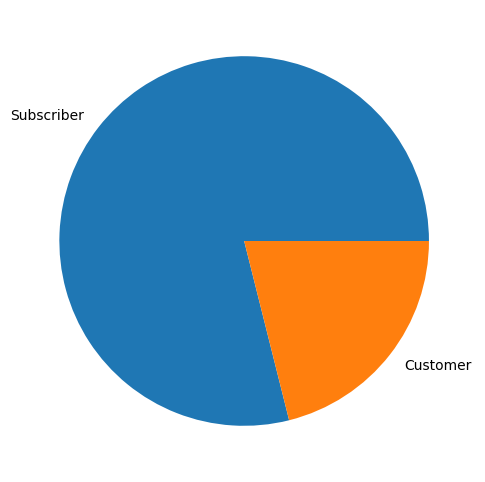

In [95]:
# YOUR CODE HERE
plt.figure(figsize=(8, 6))

plot = trip_numbers.plot(
    kind="pie", 
    color=["#1f77b4", "#ff7f0e"]
    )


### Challenge 6: Visualise subscription frequency, bar chart

Plot the same data as a bar chart.

Subscription_Type
Subscriber    113647
Customer       30368
Name: count, dtype: int64


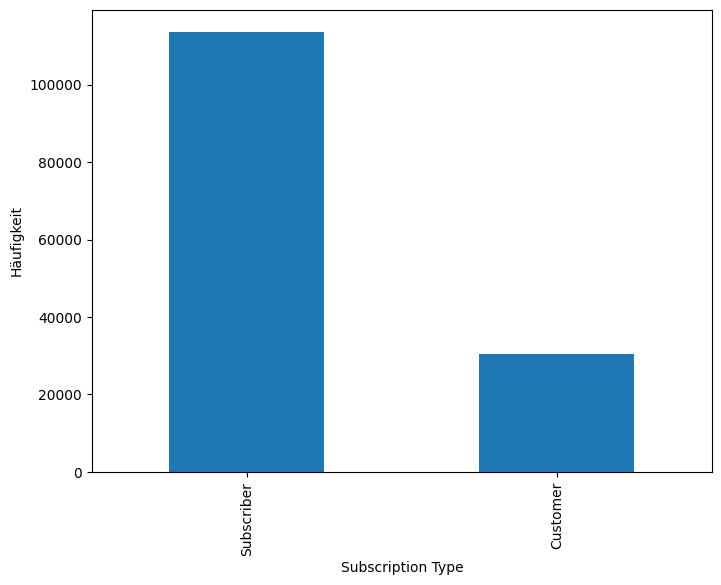

In [96]:
# YOUR CODE HERE
plt.figure(figsize=(8, 6))
print(trip_numbers)

plot = trip_numbers.plot(
    kind = "bar",
    x = "index",
    y = "values ",
    xlabel = "Subscription Type",
    ylabel = "Häufigkeit"
)
    

---

## Part 3: Station Analysis

### Challenge 7: Top 10 most popular start stations

Which 10 start stations appear most frequently in the data?

In [97]:
# YOUR CODE HERE
count_station_start = df["Start_Station"].value_counts()
#count_station_end = df
print(count_station_start[:10])

Start_Station
San Francisco Caltrain (Townsend at 4th)         9838
Harry Bridges Plaza (Ferry Building)             7343
Embarcadero at Sansome                           6545
Market at Sansome                                5922
Temporary Transbay Terminal (Howard at Beale)    5113
Market at 4th                                    5030
2nd at Townsend                                  4987
San Francisco Caltrain 2 (330 Townsend)          4976
Steuart at Market                                4913
Townsend at 7th                                  4493
Name: count, dtype: int64


### Challenge 8: 10 least popular end stations

Which 10 end stations appear least often?

In [98]:
# YOUR CODE HERE
count_station_end = df["End_Station"].value_counts()
#count_station_end = df
print(count_station_end[-10:])

End_Station
Broadway St at Battery St           205
Redwood City Medical Center         178
Castro Street and El Camino Real    129
Redwood City Public Library         117
San Mateo County Center             106
Franklin at Maple                    93
San Antonio Shopping Center          93
Broadway at Main                     56
San Jose Government Center           23
Mezes Park                            5
Name: count, dtype: int64


### Challenge 9: Cross-tabulation of start stations by subscription type

Create a table that shows the count of trips for each `start_station` segmented by `subscription_type`, including row and column totals (subtotals).

> Hint: look up `pd.crosstab()` in the documentation.

In [99]:
# YOUR CODE HERE

table = pd.crosstab(df["Start_Station"],
                    df["Subscription_Type"],
                    margins = True,
                    margins_name = "Total")

table


Subscription_Type,Customer,Subscriber,Total
Start_Station,,,
2nd at Folsom,427,3349,3776
2nd at South Park,535,3923,4458
2nd at Townsend,882,4105,4987
5th at Howard,606,2029,2635
Adobe on Almaden,75,260,335
...,...,...,...
Townsend at 7th,518,3975,4493
University and Emerson,328,106,434
Washington at Kearney,561,911,1472


---

## Part 4: Trip Duration

### Challenge 10: Explore duration

What unit do you think the `duration` column uses? Find the shortest and longest trips. How many trips are as short as the minimum?

In [100]:
# YOUR CODE HERE
# Einheit in [Sekunden]
df.head()
min_time = df["Duration"].min()
max_time = df["Duration"].max()

count_minimum = (df["Duration"] == min_time).sum()

print(min_time)
print(max_time)
number_of_min = print(count_minimum)



60
722236
17


### Challenge 11: Define and count "long" trips

Define what you consider a "long" trip (justify your threshold). How many trips meet that definition? What might explain the very long durations?

In [101]:
# YOUR CODE HERE
long_trip = 3600 # entspricht 1 Stunde in Sekunden

count_long_trips = (df["Duration"] >= long_trip).sum()

print(f"number of long trips = {count_long_trips}")

number of long trips = 5696


### Challenge 12: Plot the duration distribution

Create a histogram of the `duration` column. Does it give clear insights? If not, filter to a more meaningful range and re-plot.

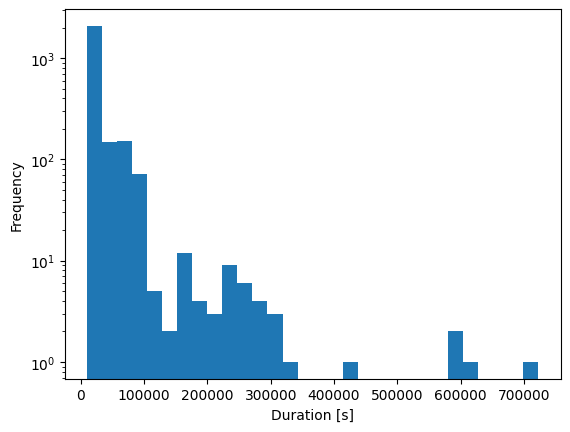

In [102]:
# YOUR CODE HERE

long_trip = 10_000
station_name_start = df["Start_Station"].unique() 
station_name_end = df["End_Station"].unique()

unique_station_names = set(station_name_start).intersection(station_name_end)

df[df["Duration"] >= long_trip]["Duration"].plot(kind = "hist",
                                                 bins = 30,
                                                 xlabel = "Duration [s]",)

plt.yscale("log")



<Axes: title={'center': 'Duration'}, xlabel='Start_Station'>

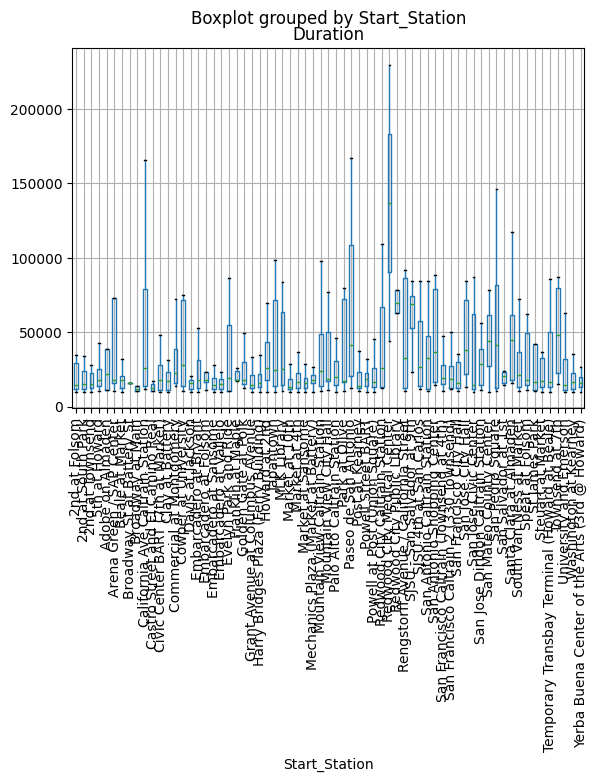

In [103]:
# Darstellung als Boxplot nach Stationsnamen
import matplotlib.pyplot as plt
filtered = df[df["Start_Station"].isin(unique_station_names)
              & (df["Duration"]>= long_trip)]


filtered.boxplot(column ="Duration",
                 by = "Start_Station",
                 rot = 90,
                 showfliers = False)

#plt.yscale("log")

---

## Part 5: Data Cleaning (Advanced)

### Challenge 13: Normalise station names

The product team wants all station names to be lowercase with underscores as separators.

Example: `South Van Ness at Market` → `south_van_ness_at_market`

Apply this transformation to both the `start_station` and `end_station` columns.

> **Do NOT use a for loop.** Use a vectorised Pandas string method instead, it will be much faster.

In [104]:
# YOUR CODE HERE


df[["Start_Station", "End_Station"]] = df[["Start_Station", "End_Station"]].apply(lambda replace: 
                                                                                  replace.str.lower().str.replace(" ", "_", regex = False))

df.head()


,Trip_ID,Duration,Start_Date,Start_Station,Start_Terminal,End_Date,End_Station,End_Terminal,Bike_num,Subscription_Type,Zip_Code
0,4576,63,8/29/2013 14:13,south_van_ness_at_market,66,8/29/2013 14:14,south_van_ness_at_market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,san_jose_city_hall,10,8/29/2013 14:43,san_jose_city_hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,mountain_view_city_hall,27,8/29/2013 10:17,mountain_view_city_hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,san_jose_city_hall,10,8/29/2013 11:30,san_jose_city_hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,south_van_ness_at_market,66,8/29/2013 12:04,market_at_10th,67,319,Subscriber,94103


### Challenge 14: Open-ended exploration

Set a 15-minute timer. Use that time to explore the data guided by your own curiosity or hypotheses. What patterns can you find?

> Time-boxing is a useful technique when exploring new data: it prevents you from falling into rabbit holes and forces you to prioritise the most interesting questions.

In [105]:
# YOUR CODE HERE